In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
project_root='/home/g202393750/Documents/Superresolution/The definitive model/'
sys.path.append(project_root)

import numpy as np
from Utils.utils_modif import *

test_data_base=f"{project_root}Data/Train/original/"

# Importation

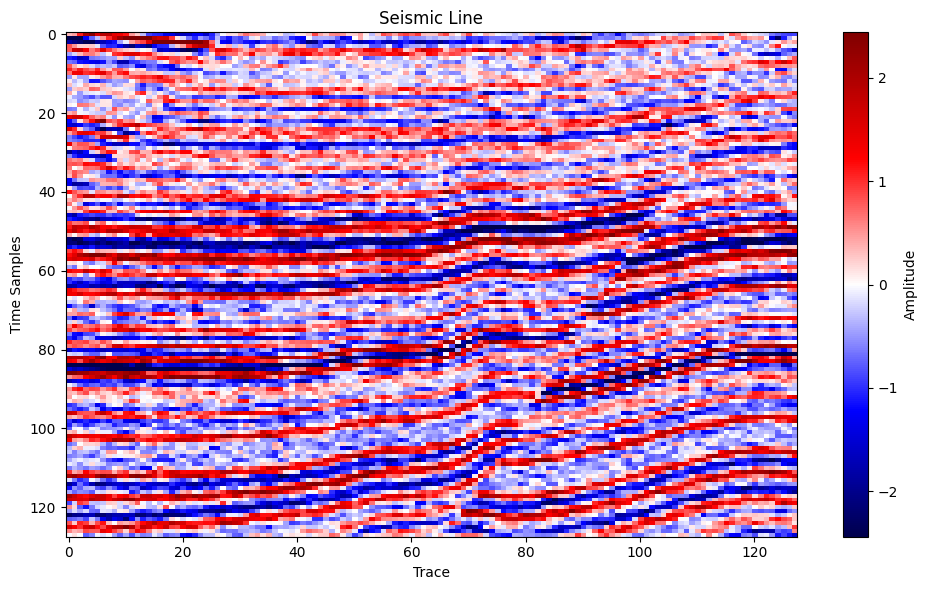

(128, 128)


In [2]:
test_data_path=f"{test_data_base}nx2.npy/3144.npy"
seismic_data_LR = np.load(test_data_path)
plot_2D_seismic(seismic_data_LR)
print(seismic_data_LR.shape)

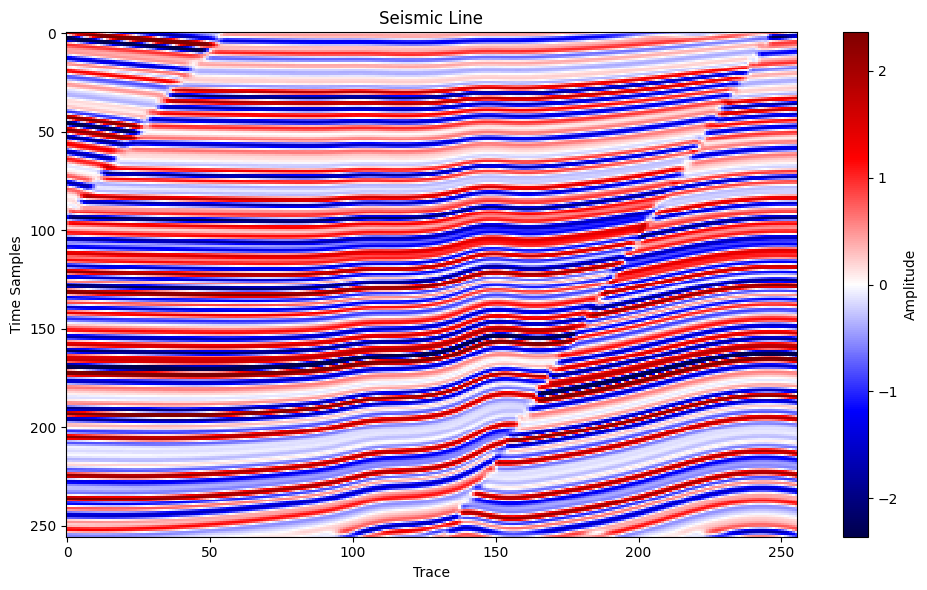

(256, 256)


In [3]:
test_data_path=f"{test_data_base}sx.npy/3144.npy"
seismic_data_HR = np.load(test_data_path)
plot_2D_seismic(seismic_data_HR)
print(seismic_data_HR.shape)

In [4]:
def trace_dropout(x, drop_prob):
    """
    Drop entire seismic traces with probability drop_prob.
    
    x: array of shape (n_traces, n_samples)
    drop_prob: float between 0 and 1
    """
    mask = np.random.rand(x.shape[0]) > drop_prob
    return x * mask[:, np.newaxis]


In [5]:
Cond_low_MT = trace_dropout(seismic_data_LR, .2)
Cond_med_MT = trace_dropout(seismic_data_LR, .4)
Cond_high_MT = trace_dropout(seismic_data_LR, .6)

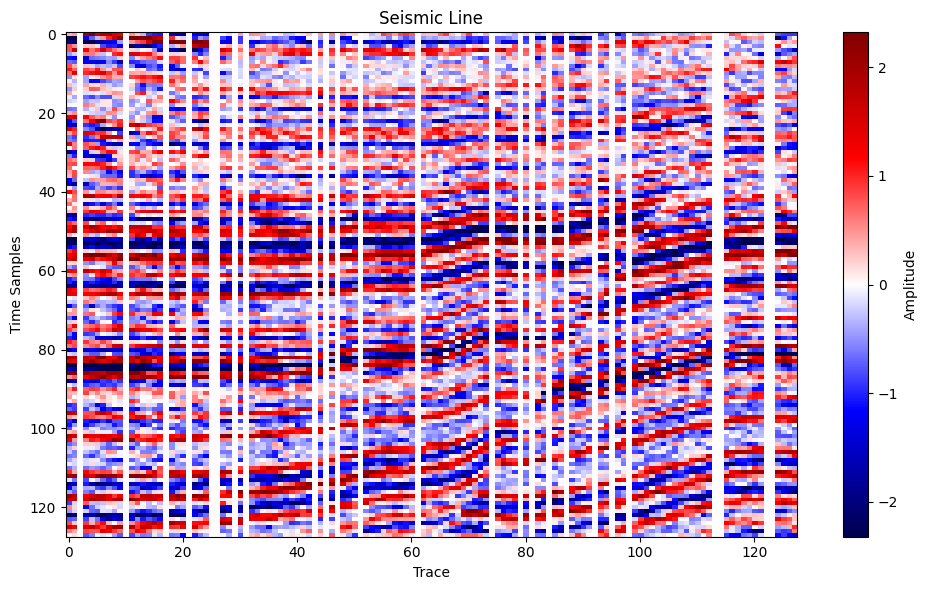

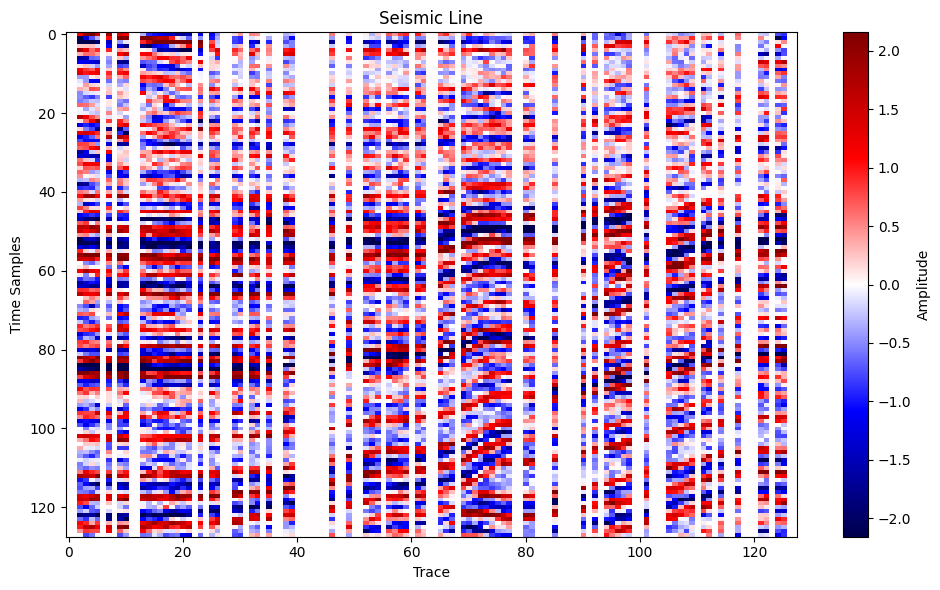

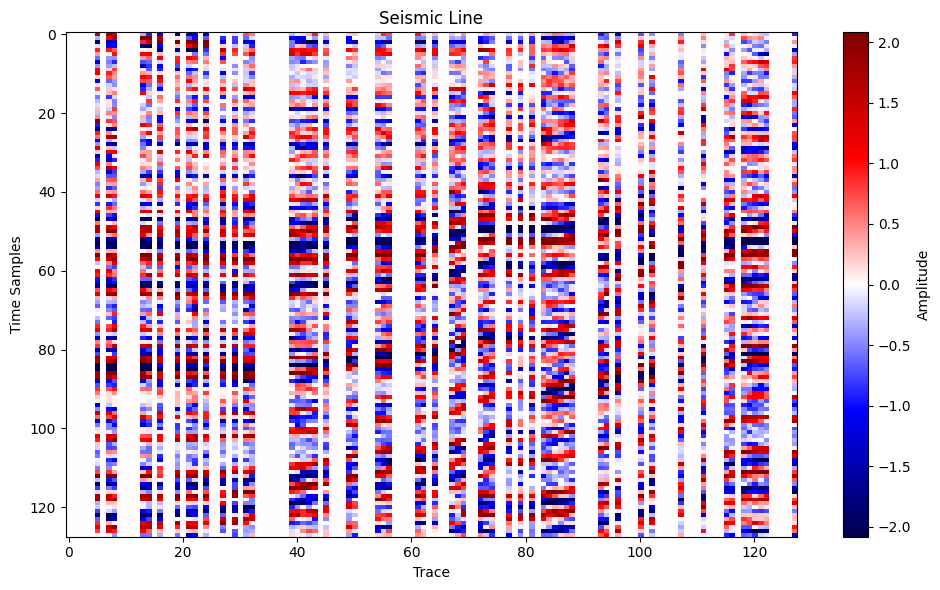

In [6]:
plot_2D_seismic(Cond_low_MT)
plot_2D_seismic(Cond_med_MT)
plot_2D_seismic(Cond_high_MT)

In [9]:
np.save(f"{project_root}Paper visualization/prediction/Reconstruction/Low_missing_traces/Cond_Low_MT.npy",
        Cond_low_MT)
np.save(f"{project_root}Paper visualization/prediction/Reconstruction/High_missing_traces/Cond_High_MT.npy",
        Cond_high_MT)
np.save(f"{project_root}Paper visualization/prediction/Reconstruction/Med_missing_traces/Cond_Med_MT.npy",
        Cond_med_MT)

In [10]:
np.save(f"{project_root}Paper visualization/prediction/Reconstruction/Low_missing_traces/GroundTruth.npy",
        seismic_data_HR)
np.save(f"{project_root}Paper visualization/prediction/Reconstruction/High_missing_traces/GroundTruth.npy",
        seismic_data_HR)
np.save(f"{project_root}Paper visualization/prediction/Reconstruction/Med_missing_traces/GroundTruth.npy",
        seismic_data_HR)